# Analiza modeli detekcji i klasyfikacji znaków drogowych

Raport wygenerowany: **2026-06-15 03:11**.

## 1. Wprowadzenie

### Opis problemu i cel

Celem projektu jest zbudowanie systemu rozpoznawania znaków drogowych działającego na urządzeniu mobilnym (pipeline PyTorch → TensorFlow Lite). System na podstawie zdjęcia z kamery musi:

1. **zlokalizować** znaki na pełnej scenie ulicznej (detekcja),
2. **rozpoznać** ich konkretny typ z 50 możliwych klas (klasyfikacja).

### Motywacja

- Rozpoznawanie znaków drogowych jest jednym z podstawowych elementów systemów wspomagania kierowcy (ADAS) - poprawia bezpieczeństwo poprzez ostrzeganie o ograniczeniach, zakazach i nakazach.
- Zadanie łączy dwa różne podproblemy widzenia komputerowego: **detekcję obiektów** (małe znaki na dużym, zróżnicowanym tle) oraz **klasyfikację wieloklasową** (50 typów znaków, z których wiele jest bardzo podobnych wizualnie - np. różne ograniczenia prędkości).
- Docelowe wdrożenie mobilne wymusza wybór lekkich architektur ("nano"/"lite" warianty) i eksport do TFLite, co dodaje wymiar kompromisu dokładność/rozmiar/szybkość do każdej decyzji projektowej.
- Dostępność kilku publicznych datasetów (niemiecki GTSRB/GTSDB i polski zbiór znaków) pozwala zbudować jedną, ujednoliconą taksonomię klas i sprawdzić, jak modele generalizują między źródłami danych z różnych krajów.

### Przyjęte podejścia

W projekcie porównano trzy podejścia do tego samego problemu:

1. **Pipeline dwuetapowy**: jednoklasowy detektor YOLO (`traffic_sign`) lokalizuje znaki na pełnym obrazie, a osobny klasyfikator (np. MobileNetV2) rozpoznaje typ każdego wycinka.
2. **Sam detektor jednoklasowy** - porównanie kilku konfiguracji bazowych YOLO (YOLOv8n / YOLO11n), z augmentacją i bez.
3. **Model recognition** - jeden model YOLO wykonujący w jednym przebiegu detekcję i klasyfikację na 50 klas.

### Streszczenie najważniejszych wyników

- Najlepszy klasyfikator wycinków znaków: **MobileNetV2**, Top-1 **99.16%**.
- Najlepszy detektor lokalizacyjny według mAP50: **yolo11n_traffic_sign_20260613-222305**, mAP50 **93.33%**.
- Najlepszy model detekcja + klasa: **yolo11n_recognition_20260614-193929**, mAP50 **77.62%**.

Raport jest samodzielny: tabele, metryki i obrazy są osadzone w notebooku.

## 2. Dane

### źródło datasetu

Dane pochodzą z trzech publicznych zbiorów dostępnych na Kaggle, zmapowanych na jedną wspólną taksonomię 50 klas (`configs/taxonomy.yaml`: 43 klasy wspólne z GTSRB/GTSDB + 7 klas unikalnych dla polskich znaków).

| Dataset | źródło | Rola |
| --- | --- | --- |
| GTSRB (German Traffic Sign Recognition Benchmark) | [Kaggle](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign) | klasyfikacja (43 klasy), wycinki kadrowane wg kolumn `Roi.*` z `Train.csv`/`Test.csv` |
| GTSDB (German Traffic Sign Detection Benchmark) | [Kaggle](https://www.kaggle.com/datasets/safabouguezzi/german-traffic-sign-detection-benchmark-gtsdb) | tylko detekcja (pełne scenki uliczne, te same 43 klasy co GTSRB) |
| Polish Traffic Signs Dataset | [Kaggle](https://www.kaggle.com/datasets/chriskjm/polish-traffic-signs-dataset) | klasyfikacja (19 kodów polskich znaków zmapowanych w `configs/datasets/polish.yaml`, w tym 7 nowych klas bez odpowiednika w GTSRB) + własny zbiór detekcyjny (jednoklasowy) |

GTSDB nie jest używane do klasyfikacji - jego wycinki w ~47% duplikują obrazy z GTSRB (te same nagrania), patrz sekcja "Trening" → "Problemy napotkane".

### Eksploracja

**Zbiór klasyfikacyjny** (`data/processed/classification/manifest.csv`):

| Statystyka | Wartość |
| --- | --- |
| Liczba obrazów (train+val+test) | 53 771 |
| Liczba klas | 50 |
| Podział train / val / test | 36 607 / 4 237 / 12 927 |
| Obrazy z GTSRB | 51 839 (43 klasy) |
| Obrazy z polskiego zbioru | 1 932 (klasy specyficzne dla Polski + część wspólnych) |
| Najliczniejsza klasa | `yield` - 3 067 obrazów |
| Najmniej liczna klasa | `no_right_turn` - 53 obrazy |

Rozkład 50 klas (liczba obrazów łącznie ze wszystkich splitów):

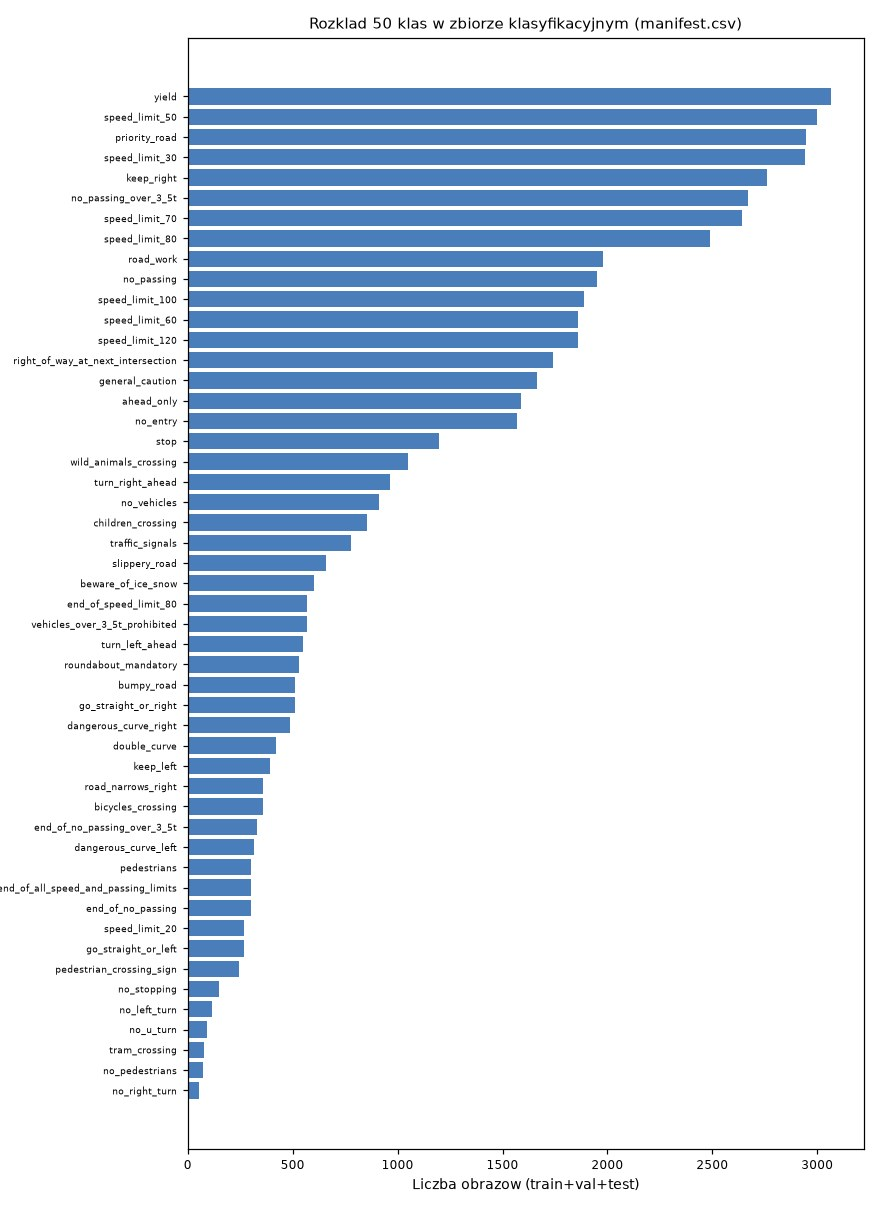

Rozkład jest silnie niezbalansowany: klasy popularne w GTSRB (np. ograniczenia prędkości, znaki ostrzegawcze) mają tysiące przykładów, a klasy dodane wyłącznie z polskiego zbioru (np. `tram_crossing`, `no_right_turn`) - od kilkudziesięciu do kilkuset.

**Zbiór detekcyjny** (`data/processed/detection/`, format YOLO, jedna klasa `traffic_sign`):

| Split | Liczba obrazów / etykiet |
| --- | --- |
| train | 1 409 |
| val | 298 |
| test | 314 |

### Przykładowe obrazy

Przykładowe wycinki znaków z 12 wybranych klas (mieszanka klas częstych i rzadkich, GTSRB i polskiego zbioru):

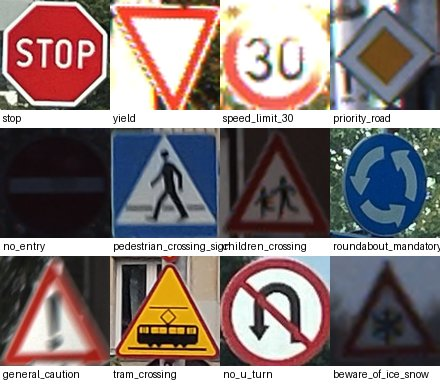

### Preprocessing i augmentacja

**Klasyfikacja** (`src/classification/train.py`):

- Wszystkie obrazy są skalowane do `224x224` i normalizowane wg statystyk ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) - wymagane przez pretrenowane backbone'y (MobileNetV2, EfficientNet-Lite0, SqueezeNet1.1).
- Domyślne augmentacje treningowe: `ColorJitter` (brightness/contrast/saturation = 0.2), `RandomRotation(10°)`, `RandomAffine` (translacja 10%, skala 0.9-1.1, shear 5°), `RandomPerspective` (p=0.3), `GaussianBlur` (p=0.3) oraz `RandomErasing` (p=0.1).
- GTSRB jest kadrowane wg kolumn `Roi.*` (`crop_margin=0.0`, obrazy są już ciasno przycięte); polski zbiór dostarcza gotowe wycinki w strukturze `ImageFolder`.

**Detekcja** (Ultralytics YOLO): domyślny pipeline obejmuje augmentacje HSV (`hsv_h/s/v`), `translate`, `scale`, `fliplr`, `mosaic`, `mixup`/`cutmix`/`copy_paste`, `erasing` oraz `auto_augment=randaugment`. W eksperymentach porównano trenowanie z tym domyślnym zestawem oraz z flagą `--no-augmentations`, która zeruje wszystkie powyższe parametry - szczegóły i wyniki w sekcji "Wyniki" → "Wpływ augmentacji na wynik detekcji".

## 3. Model/e i metoda/y

### 3.1 Detekcja: YOLO (YOLOv8n / YOLO11n)

Do detekcji wybrano rodzinę YOLO, ponieważ jest to praktyczny kompromis między dokładnością, szybkością działania i łatwością wdrożenia na urządzeniach mobilnych.

Architektury `yolov8n` i `yolo11n` to jednoetapowe (anchor-free), w pełni konwolucyjne detektory z najmniejszych wariantów "nano" rodziny Ultralytics YOLO - zaprojektowane pod urządzenia o ograniczonych zasobach.

Argumenty za wyborem YOLO:

- **Jednoprzebiegowa detekcja**: model w jednym przebiegu przewiduje położenie obiektu i confidence, co jest istotne dla pracy na obrazie z kamery.
- **Niska złożoność wariantów nano**: `yolo11n` i `yolov8n` są wystarczająco małe, aby rozważać eksport do TFLite i użycie w aplikacji mobilnej.
- **Dojrzałe narzędzia treningowe**: Ultralytics zapewnia gotowy pipeline trenowania, walidacji, wizualizacji i eksportu.
- **Zgodność z problemem**: detekcja znaków drogowych wymaga lokalizacji małych obiektów na pełnym zdjęciu; klasyczny klasyfikator obrazu nie rozwiązuje tego etapu.
- **Możliwość dwóch strategii**: YOLO może działać jako detektor jednoklasowy w pipeline z klasyfikatorem albo jako model recognition wykonujący detekcję i klasyfikację w jednym kroku.

**Hiperparametry treningu detektora** (`src/detection/cli.py`, wartości domyślne):

| Parametr | Wartość |
| --- | --- |
| epochs | 50 |
| img-size | 320 |
| batch-size | 16 |
| lr0 | 0.001 |
| patience | 10 |
| workers | 4 |
| seed | 67 |
| single_cls | True |
| conf (próg do wizualizacji) | 0.25 |
| eval-conf (próg do mAP) | 0.001 |

### 3.2 Klasyfikacja wycinków: 4 architektury

MobileNetV2 wybrano jako główny klasyfikator drugiego etapu, ponieważ jest lekki, dobrze wspierany w ekosystemie mobilnym i osiągnął bardzo wysoką dokładność na wycinkach znaków. Pozostałe trzy architektury (EfficientNet-Lite0, SqueezeNet1.1, CustomCNN) stanowią punkty odniesienia o innym rozmiarze i pochodzeniu wag.

| Model | Architektura | Wagi początkowe | Parametry |
| --- | --- | --- | --- |
| MobileNetV2 | torchvision `mobilenet_v2`, głowica liniowa zamieniona na `Linear(last_channel, 50)` | ImageNet | 2 287 922 |
| EfficientNet-Lite0 | timm `tf_efficientnet_lite0` - wariant "Lite" (bez squeeze-excite, ReLU6, pooling o ustalonym rozmiarze) zaprojektowany pod eksport do TFLite | ImageNet | 3 435 058 |
| SqueezeNet1.1 | torchvision `squeezenet1_1`, głowica `Conv2d(512, 50, kernel_size=1)` | ImageNet | 748 146 |
| CustomCNN | sieć od zera: warstwa `conv-bn-relu` + 4 bloki depthwise-separable (styl MobileNet) + global average pooling + dropout 0.3 + liniowa głowica | brak (trening od zera) | 168 434 |

**Hiperparametry treningu klasyfikatora** (`src/classification/train.py`, wspólne dla wszystkich modeli):

| Parametr | Wartość |
| --- | --- |
| img-size | 224x224 |
| optimizer | Adam |
| learning rate | 0.001 |
| liczba klas | 50 |
| normalizacja | ImageNet mean/std |

### 3.3 Model recognition (detekcja + klasyfikacja jednocześnie)

Trzecim podejściem jest pojedynczy model `yolo11n` trenowany od razu na 50-klasowym zadaniu detekcja+klasyfikacja (`yolo11n_recognition_*`), upraszczający architekturę wdrożenia do jednego modelu TFLite - kosztem dokładności (patrz "Wyniki").

## 4. Trening

### Przebieg treningu

**Klasyfikacja**: każda z 4 architektur (MobileNetV2, EfficientNet-Lite0, SqueezeNet1.1, CustomCNN) była trenowana wielokrotnie - od krótkich przebiegów diagnostycznych (1 epoka) do głównych przebiegów (5-10 epok). Dodatkowo `python -m src.classification.run_experiments` wykonał porównawczy run dla wszystkich 4 architektur, każdą trenując dwukrotnie (5 epok, Adam, lr=0.001): raz bez augmentacji danych treningowych, raz z nią (wyniki w sekcji "Wyniki" → "Wpływ augmentacji na wynik klasyfikacji").  Dodatkowo wykonano serię przebiegów z **balansowaniem klas do średniej** (`--balance-to-mean`: over/under sampling w zbiorze train, 10 epok, 4 architektury bez YOLO-cls) — wyniki w sekcji "Wyniki" → "Balansowanie klas: over/under sampling do średniej".

Każdy przebieg zapisuje checkpoint `.pt` oraz pełne podsumowanie `.json` (hiperparametry, historia epok, metryki, czas treningu).

**Detekcja**: `python -m src.detection.train` dla każdej konfiguracji (`yolov8n.pt` / `yolo11n.pt`, z domyślną augmentacją lub `--no-augmentations`, przy `img-size` 320 lub 640) wykonuje pełen cykl: (1) ewaluacja modelu bazowego (COCO-pretrained) przed dotrenowaniem, (2) fine-tuning na jednoklasowym zbiorze `traffic_sign`, (3) ewaluacja po dotrenowaniu, (4) zapis wizualizacji porównawczych i `summary.json` z metrykami dla obu etapów.

**Recognition**: model `yolo11n` trenowany od razu na 50-klasowym zadaniu detekcja+klasyfikacja, w dwóch konfiguracjach (320x320 / 50 epok i 640x640 / 100 epok).

### Problemy napotkane

1. **Duplikaty między GTSDB i GTSRB**: wycinki znaków generowane z GTSDB w ~47% duplikowały obrazy z GTSRB (te same nagrania), co grożiło przeciekiem (leakage) między zbiorami train/val/test. Rozwiązanie: GTSDB jest używane wyłącznie do detekcji, klasyfikacja korzysta tylko z GTSRB i polskiego zbioru.
2. **Przeciek train/val w GTSRB**: GTSRB zawiera ~30 prawie identycznych kolejnych ramek (track) na fizyczny znak. Podział per-ramka umieszczał prawie identyczne ramki tego samego znaku jednocześnie w train i val, sztucznie zawyżając dokładność walidacyjną. Rozwiązanie: podział wykonywany na kluczu `(ClassId, TrackId)` (cały track w jednym splicie), dodatkowo wprowadzono augmentacje (`RandomAffine`, `RandomPerspective`, `GaussianBlur`, `RandomErasing`), aby model nie uczył się "na pamięć" prawie identycznych ramek w obrębie tracku.
3. **Brak widoczności postępu treningu**: długie epoki działały "po ciemku". Rozwiązanie: dodano interaktywne pasy postępu (tqdm) z bieżącym loss/acc dla train, val i test.
4. **Twardo zakodowana nazwa "YOLO11n" w module detekcji**: nazwy przebiegów, pole `"model"` w `summary.json`, tytuły paneli wizualizacji oraz komunikaty konsolowe zawierały zaszyty na stałe ciąg `"YOLO11n"`/`"yolo11n"` niezależnie od faktycznie użytego `--base-model` - katalog `yolo11n_traffic_sign_20260614-210909/` w rzeczywistości zawierał wyniki dla `yolov8n.pt`. Rozwiązanie: nazwa detektora jest wyprowadzana dynamicznie z `--base-model` (`Path(args.base_model).stem`) i propagowana do nazwy przebiegu, podsumowania, wizualizacji i logów.

## 5. Wyniki

### Metryki

Eksperymenty obejmowały dwa zadania:

1. **Klasyfikacja wycinków znaków**: model otrzymuje już wycięty znak i przewiduje jedną z klas.
2. **Detekcja na pełnym obrazie**: model otrzymuje pełną scenę i przewiduje położenie znaku. W wariancie recognition przewiduje również klasę znaku.

Do oceny klasyfikacji użyto Top-1 accuracy i Top-5 accuracy. Do oceny detekcji użyto Precision@50, Recall@50, F1@50, mAP50 oraz mAP50-95.

Należy zaznaczyć, że wyniki klasyfikatorów i detektorów nie są bezpośrednio tym samym zadaniem: klasyfikator pracuje na wycinkach, a detektor na pełnych obrazach.


### Wyniki klasyfikatorów

| Model | Zadanie | Liczba klas | Wejście | Epoki | Top-1 | Top-5 | Parametry |
| --- | --- | --- | --- | --- | --- | --- | --- |
| MobileNetV2 | klasyfikacja wycinków | 50 | 224x224 | 10 | 99.16% | - | 2 287 922 |
| YOLO11n-cls | klasyfikacja wycinków | 50 | 224x224 | 50 | 97.79% | 99.98% | - |

Interpretacja: MobileNetV2 osiąga najwyższy wynik Top-1 i jest preferowanym klasyfikatorem w wariancie dwuetapowym.

### Wpływ augmentacji na wynik klasyfikacji

Poniższe wyniki pochodzą z `models/experiments_log.csv` (wygenerowanego przez `python -m src.classification.run_experiments`) — runu porównawczego, w którym każdą z czterech architektur klasyfikatora wytrenowano dwukrotnie (5 epok, optymalizator Adam, lr=0.001): raz bez augmentacji danych treningowych, raz z nią.

| Model | Wariant | Run | Train Acc | Val Acc | Test Acc | Test Loss |
| --- | --- | --- | --- | --- | --- | --- |
| CustomCNN | bez augmentacji | custom_cnn_20260613-221245 | 96.11% | 92.40% | 90.88% | 0.3289 |
| CustomCNN | z augmentacją | custom_cnn_20260613-221746 | 93.88% | 93.06% | 89.61% | 0.4029 |
| EfficientNet-Lite0 | bez augmentacji | efficientnet_lite0_20260613-222752 | 99.64% | 98.18% | 98.19% | 0.0682 |
| EfficientNet-Lite0 | z augmentacją | efficientnet_lite0_20260613-223808 | 99.60% | 99.72% | 98.72% | 0.0577 |
| MobileNetV2 | bez augmentacji | mobilenet_v2_20260613-224752 | 99.58% | 97.83% | 98.14% | 0.0722 |
| MobileNetV2 | z augmentacją | mobilenet_v2_20260613-225710 | 99.27% | 97.12% | 97.15% | 0.1080 |
| SqueezeNet | bez augmentacji | squeezenet_20260613-230151 | 98.94% | 97.36% | 96.87% | 0.1530 |
| SqueezeNet | z augmentacją | squeezenet_20260613-230713 | 98.11% | 96.55% | 96.39% | 0.1552 |

### Zmiana po włączeniu augmentacji

| Model | Zmiana Test Acc | Zmiana Test Loss | Interpretacja |
| --- | --- | --- | --- |
| CustomCNN | -1.27 pp | +0.0740 | pogorszenie |
| EfficientNet-Lite0 | +0.53 pp | -0.0105 | poprawa |
| MobileNetV2 | -0.99 pp | +0.0358 | pogorszenie |
| SqueezeNet | -0.48 pp | +0.0022 | nieznaczne pogorszenie |

W przeciwieństwie do detektorów (patrz "Wpływ augmentacji na wynik detekcji"), przy zaledwie 5 epokach treningu augmentacja danych nie przyniosła korzyści większości klasyfikatorów wycinków — jedynie EfficientNet-Lite0 zyskał na Test Accuracy. Krótki trening prawdopodobnie nie zdążył wykorzystać dodatkowej wariancji wprowadzanej przez augmentację. Wynik MobileNetV2 z tej tabeli (98.14% bez augmentacji, 5 epok) to osobny eksperyment porównawczy i nie należy go mylić z głównym wynikiem MobileNetV2 z tabeli "Wyniki klasyfikatorów" (99.16%, 10 epok).

### Balansowanie klas: over/under sampling do średniej

Zbiór treningowy klasyfikacji jest **silnie niezbalansowany** (min. 37 vs max. 2097 próbek na klasę, średnia 734). W celu ograniczenia dominacji licznych klas wprowadzono strategię **over/under sampling do średniej liczności klasy w zbiorze train** (`--balance-to-mean` w `src/classification/train.py`).

**Algorytm:**
1. Dla każdej klasy obecnej w train policz liczbę próbek.
2. Wyznacz cel: `target = round(średnia_liczność_klas)`.
3. Klasy z mniej niż 734 próbek — **oversampling** (losowe powtórzenia z augmentacją).
4. Klasy z więcej niż 734 próbek — **undersampling** (losowy podzbiór).
5. Val/test pozostają bez zmian (naturalna dystrybucja).

Po balansowaniu: **36,700** próbek train (32 klas oversamplowanych, 18 undersamplowanych), **734** próbek na klasę.

**Konfiguracja eksperymentu** (wspólna dla 4 architektur, bez YOLO-cls):
- 10 epok, batch 32, Adam lr=0.001, augmentacja włączona
- Flaga: `--balance-to-mean`

#### Wyniki po balansowaniu (10 epok)

| Model | Run | Sampling | Train Acc | Val Acc | Test Acc | Test Loss |
| --- | --- | --- | --- | --- | --- | --- |
| CustomCNN | custom_cnn_20260615-172105 | over/under → średnia | 97.72% | 98.64% | 94.61% | 0.2074 |
| EfficientNet-Lite0 | efficientnet_lite0_20260615-174658 | over/under → średnia | 99.63% | 99.66% | 99.08% | 0.0353 |
| MobileNetV2 | mobilenet_v2_20260615-181001 | over/under → średnia | 99.60% | 99.47% | 97.86% | 0.0872 |
| SqueezeNet | squeezenet_20260615-182027 | over/under → średnia | 98.05% | 97.84% | 95.51% | 0.1891 |

#### Porównanie z próbkowaniem naturalnym

| Model | Referencja (naturalne) | Test Acc (naturalne) | Test Acc (balansowane) | Δ Test Acc | Uwagi |
| --- | --- | --- | --- | --- | --- |
| CustomCNN | custom_cnn_20260613-221245 (5 ep.) | 90.88% | 94.61% | +3.73 pp | próbkowanie naturalne, bez augmentacji |
| EfficientNet-Lite0 | efficientnet_lite0_20260613-223808 (5 ep.) | 98.72% | 99.08% | +0.36 pp | próbkowanie naturalne, z augmentacją |
| MobileNetV2 | mobilenet_v2_20260614-220550 (10 ep.) | 99.16% | 97.86% | -1.31 pp | próbkowanie naturalne, z augmentacją |
| SqueezeNet | squeezenet_20260613-230151 (5 ep.) | 96.87% | 95.51% | -1.36 pp | próbkowanie naturalne, bez augmentacji |

**Interpretacja:**
- **CustomCNN** zyskał najwięcej (+3.7 pp) — sieć od zera silniej korzysta z wyrównania klas.
- **EfficientNet-Lite0** nieznacznie poprawił wynik (+0.36 pp) względem 5-epokowej referencji z augmentacją.
- **MobileNetV2** stracił −1.31 pp względem 10-epokowego treningu na naturalnej dystrybucji — model z wagami ImageNet mógł już dobrze wykorzystywać dominujące klasy, a utrata ich reprezentacji pogorszyła generalizację.
- **SqueezeNet** nieznacznie spadł (−1.36 pp) względem 5-epokowej referencji; różnica epok utrudnia bezpośrednie porównanie.

Balansowanie do średniej poprawia wyniki słabszych architektur na niezbalansowanych danych, ale nie zawsze przekłada się na lepszą dokładność globalną u najlepszego klasyfikatora (MobileNetV2).


### Wyniki detektorów lokalizacyjnych

| Run | Model bazowy | Augmentacja | Wejście | Precision@50 | Recall@50 | F1@50 | mAP50 | mAP50-95 | Pred / GT |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| yolo11n_traffic_sign_20260613-222305 | yolov8n.pt | domyślna YOLO | 320x320 | 18.36% | 97.16% | 30.89% | 93.33% | 71.02% | 3 164 / 598 |
| yolo11n_traffic_sign_20260613-205016 | yolo11n.pt | domyślna YOLO | 320x320 | 14.26% | 96.32% | 24.85% | 93.30% | 71.00% | 4 038 / 598 |
| yolo11n_traffic_sign_20260613-234452 | yolov8n.pt | domyślna YOLO | 320x320 | 87.38% | 90.30% | 88.82% | 89.38% | 70.19% | 618 / 598 |
| yolo11n_traffic_sign_20260613-230547 | yolo11n.pt | domyślna YOLO | 320x320 | 85.03% | 89.30% | 87.11% | 88.18% | 69.04% | 628 / 598 |
| yolov8n_localization_20260615-013627 | yolov8n.pt | domyślna YOLO | 320x320 | 94.26% | 85.12% | 89.46% | 84.61% | 67.38% | 540 / 598 |
| yolov8n_localization_noaug_20260615-025239 | yolov8n.pt | wyłączona | 320x320 | 64.93% | 87.29% | 74.47% | 84.23% | 61.65% | 804 / 598 |
| yolo11n_localization_noaug_20260615-030149 | yolo11n.pt | wyłączona | 320x320 | 29.88% | 89.13% | 44.75% | 84.05% | 60.12% | 1 784 / 598 |

Wysoki Recall oznacza, że model odnajduje większość znaków. Wysoka Precision oznacza mniej fałszywych detekcji. W praktycznej aplikacji należy dobrać próg confidence tak, aby zachować kompromis między tymi wartościami.

### Wpływ augmentacji na wynik detekcji

| Model | Wariant | Run | mAP50 | mAP50-95 | Precision@50 | Recall@50 | Pred / GT |
| --- | --- | --- | --- | --- | --- | --- | --- |
| YOLOv8n | z augmentacją | yolov8n_localization_20260615-013627 | 84.61% | 67.38% | 94.26% | 85.12% | 540 / 598 |
| YOLOv8n | bez augmentacji | yolov8n_localization_noaug_20260615-025239 | 84.23% | 61.65% | 64.93% | 87.29% | 804 / 598 |
| YOLO11n | z augmentacją | yolo11n_traffic_sign_20260613-205016 | 93.30% | 71.00% | 14.26% | 96.32% | 4 038 / 598 |
| YOLO11n | bez augmentacji | yolo11n_localization_noaug_20260615-030149 | 84.05% | 60.12% | 29.88% | 89.13% | 1 784 / 598 |

### Zmiana po wyłączeniu augmentacji

| Model | Zmiana mAP50 po wyłączeniu | Zmiana mAP50-95 po wyłączeniu | Zmiana Precision@50 | Zmiana Recall@50 | Interpretacja |
| --- | --- | --- | --- | --- | --- |
| YOLOv8n | -0.38 pp | -5.73 pp | -29.33 pp | +2.17 pp | pogorszenie jakości po wyłączeniu augmentacji |
| YOLO11n | -9.25 pp | -10.88 pp | +15.61 pp | -7.19 pp | pogorszenie jakości po wyłączeniu augmentacji |

Wyniki wskazują, że augmentacja poprawiała mAP50 i mAP50-95 w obu porównanych wariantach. Po jej wyłączeniu spadła przede wszystkim jakość uogólniania, szczególnie widoczna w mAP50-95. Dla YOLOv8n bez augmentacji wzrosła precyzja względem jednego runu z augmentacją, ale odbyło się to przy niższym mAP50-95, co sugeruje mniej stabilne dopasowanie lokalizacji.

#### Jakie augmentacje były wyłączane

Runy bez augmentacji zostały uruchomione z flagą `--no-augmentations`. Flaga ustawia na zero lub `None` następujące parametry treningu YOLO:

| Parametr | Wariant z augmentacją | Wariant bez augmentacji |
| --- | --- | --- |
| `hsv_h`, `hsv_s`, `hsv_v` | aktywne | `0.0` |
| `translate` | aktywne | `0.0` |
| `scale` | aktywne | `0.0` |
| `fliplr` | aktywne | `0.0` |
| `mosaic` | aktywne | `0.0` |
| `mixup`, `cutmix`, `copy_paste` | zgodnie z konfiguracją YOLO | `0.0` |
| `erasing` | aktywne | `0.0` |
| `auto_augment` | `randaugment` | `None` |

Dzięki temu porównanie jest eksperymentem kontrolnym: zmieniana jest augmentacja, a pozostałe kluczowe parametry, takie jak rozmiar obrazu, liczba epok, seed i batch size, pozostają zgodne w obrębie danej pary modeli.


### Model YOLO recognition: detekcja i klasyfikacja jednocześnie

| Run | Wejście | Epoki | Precision@50 | Recall@50 | F1@50 | mAP50 | mAP50-95 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| yolo11n_recognition_20260614-193929 | 640x640 | 100 | 11.33% | 98.65% | 20.32% | 77.62% | 59.98% |
| yolo11n_recognition_20260614-193320 | 320x320 | 50 | 8.94% | 80.41% | 16.09% | 53.13% | 28.04% |

Ten wariant upraszcza wdrożenie, ponieważ zastępuje pipeline detektor + klasyfikator jednym modelem. Jego ograniczeniem w aktualnym eksperymencie jest mniejszy zakres klas niż w klasyfikatorze MobileNetV2.

### Porównanie z baseline

Jako baseline przyjęto model YOLO **bez dotrenowania** (wagi COCO-pretrained, 80 klas), oceniany w trybie class-agnostic na zbiorze `traffic_sign` (tak jak opisano w `src/detection/evaluate.py` - każda predykcja niezależnie od klasy COCO jest traktowana jako "potencjalny znak"). Poniżej porównanie metryk przed i po fine-tuningu dla dwóch przebiegów:

| Run | Model bazowy | Etap | mAP50 | Recall@50 | Precision@50 |
| --- | --- | --- | --- | --- | --- |
| yolo11n_traffic_sign_20260614-204831 | yolo11n.pt | baseline (COCO-pretrained) | 7.37% | 74.08% | 2.19% |
| yolo11n_traffic_sign_20260614-204831 | yolo11n.pt | po fine-tuningu | 92.90% | 96.32% | 13.80% |
| yolo11n_traffic_sign_20260614-210909 | yolov8n.pt | baseline (COCO-pretrained) | 6.90% | 74.58% | 2.17% |
| yolo11n_traffic_sign_20260614-210909 | yolov8n.pt | po fine-tuningu | 92.55% | 95.65% | 15.87% |

Fine-tuning na danych `traffic_sign` poprawia mAP50 o ~+85 pp dla obu modeli bazowych. Baseline COCO-pretrained ma relatywnie wysoki Recall (model wykrywa wiele obiektów ogólnie), ale ekstremalnie niski Precision - traktuje praktycznie każdy obiekt jako potencjalny znak. Dotrenowanie na jednoklasowym zbiorze `traffic_sign` znacząco redukuje liczbę fałszywych trafień przy zachowaniu wysokiego Recall.

### Artefakty wdrożeniowe TFLite

| Model / wariant | Plik | Rozmiar | Wejście | Wyjście |
| --- | --- | --- | --- | --- |
| YOLO lokalizacyjny | models/tflite/yolo_detector.tflite | 11.57 MB | [1, 320, 320, 3] | [1, 5, 2100] |
| MobileNetV2 | models/tflite/classifire_mobilenet.tflite | 8.69 MB | [1, 224, 224, 3] | [1, 50] |
| YOLO recognition | models/tflite/yolo_detector_classifier.tflite | 10.15 MB | [1, 640, 640, 3] | [1, 47, 8400] |
| YOLO11n-cls | models/classification_yolo/yolo11n-cls_20260614-201616/weights/best_saved_model/best_float32.tflite | 6.10 MB | [1, 224, 224, 3] | [1, 50] |

### Wizualizacje jakościowe

### yolo11n_traffic_sign_20260613-205016

Źródło obrazu: `models/detection/yolo11n_traffic_sign_20260613-205016/visualizations/test_comparison_overview_5samples.jpg`

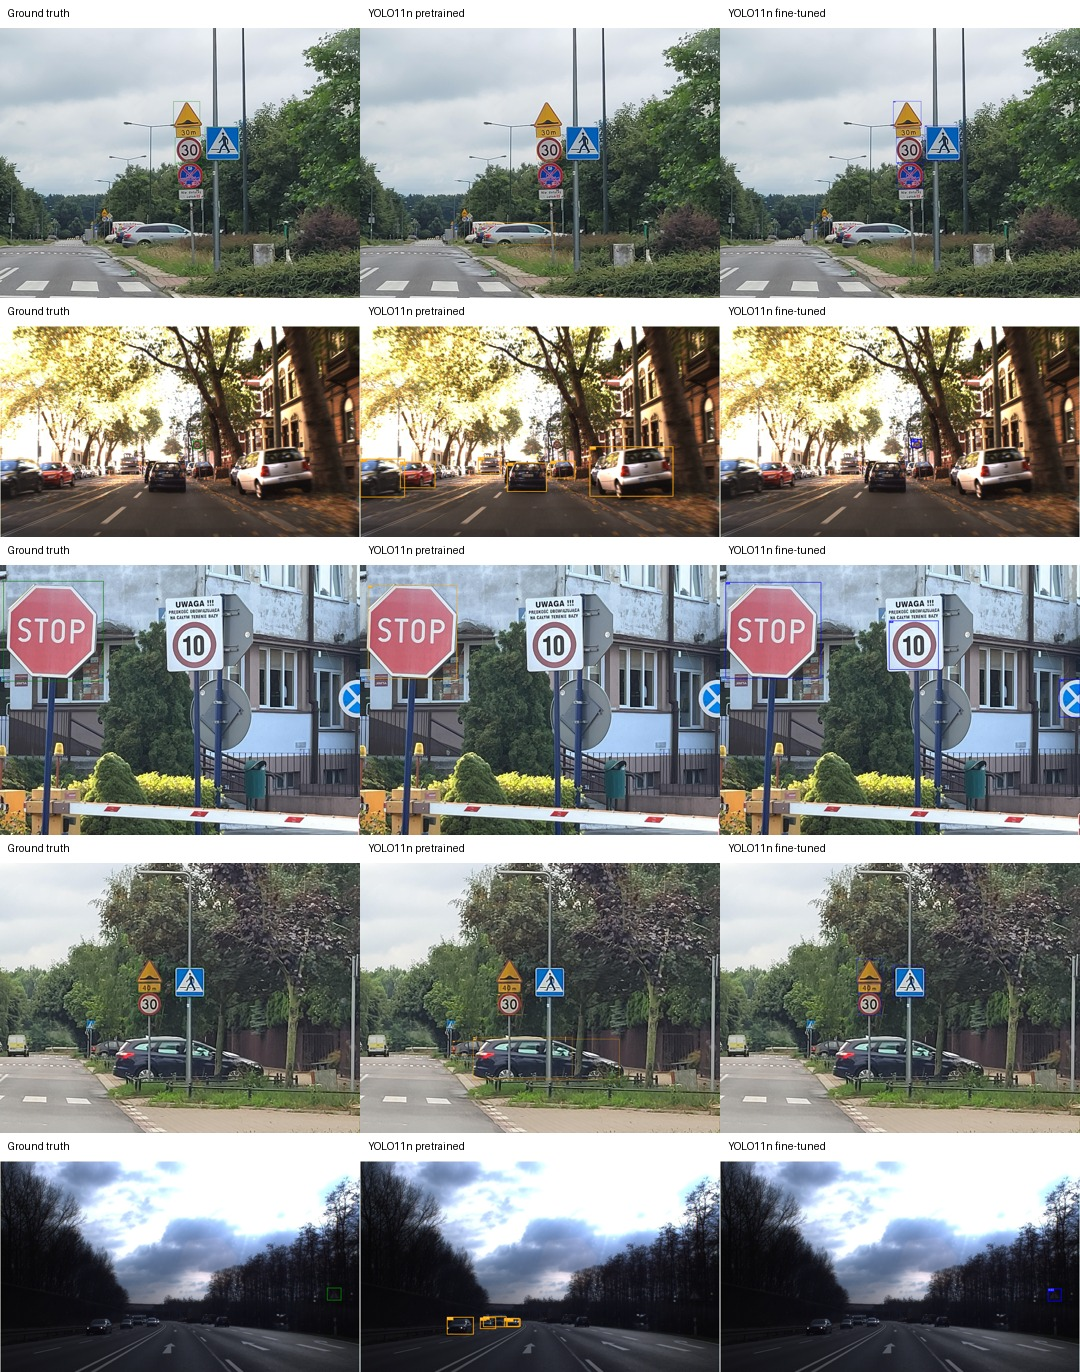

### yolo11n_localization_noaug_20260615-030149

Źródło obrazu: `models/detection/yolo11n_localization_noaug_20260615-030149/visualizations/test_comparison_overview_5samples.jpg`

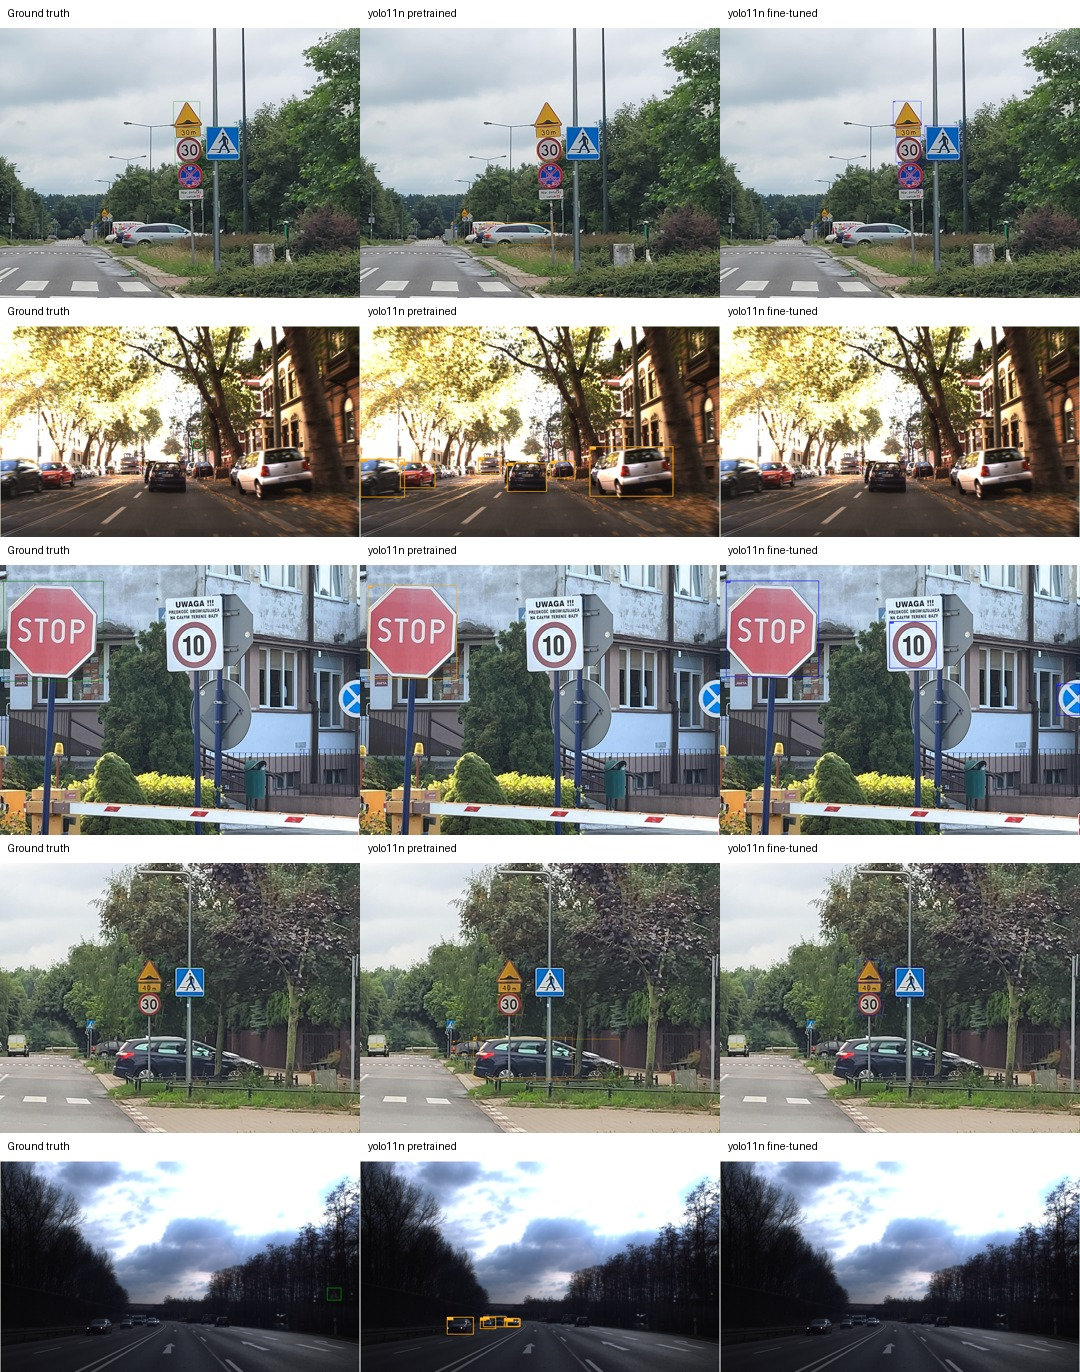

### yolov8n_localization_20260615-013627

Źródło obrazu: `models/detection/yolov8n_localization_20260615-013627/visualizations/test_comparison_overview_5samples.jpg`

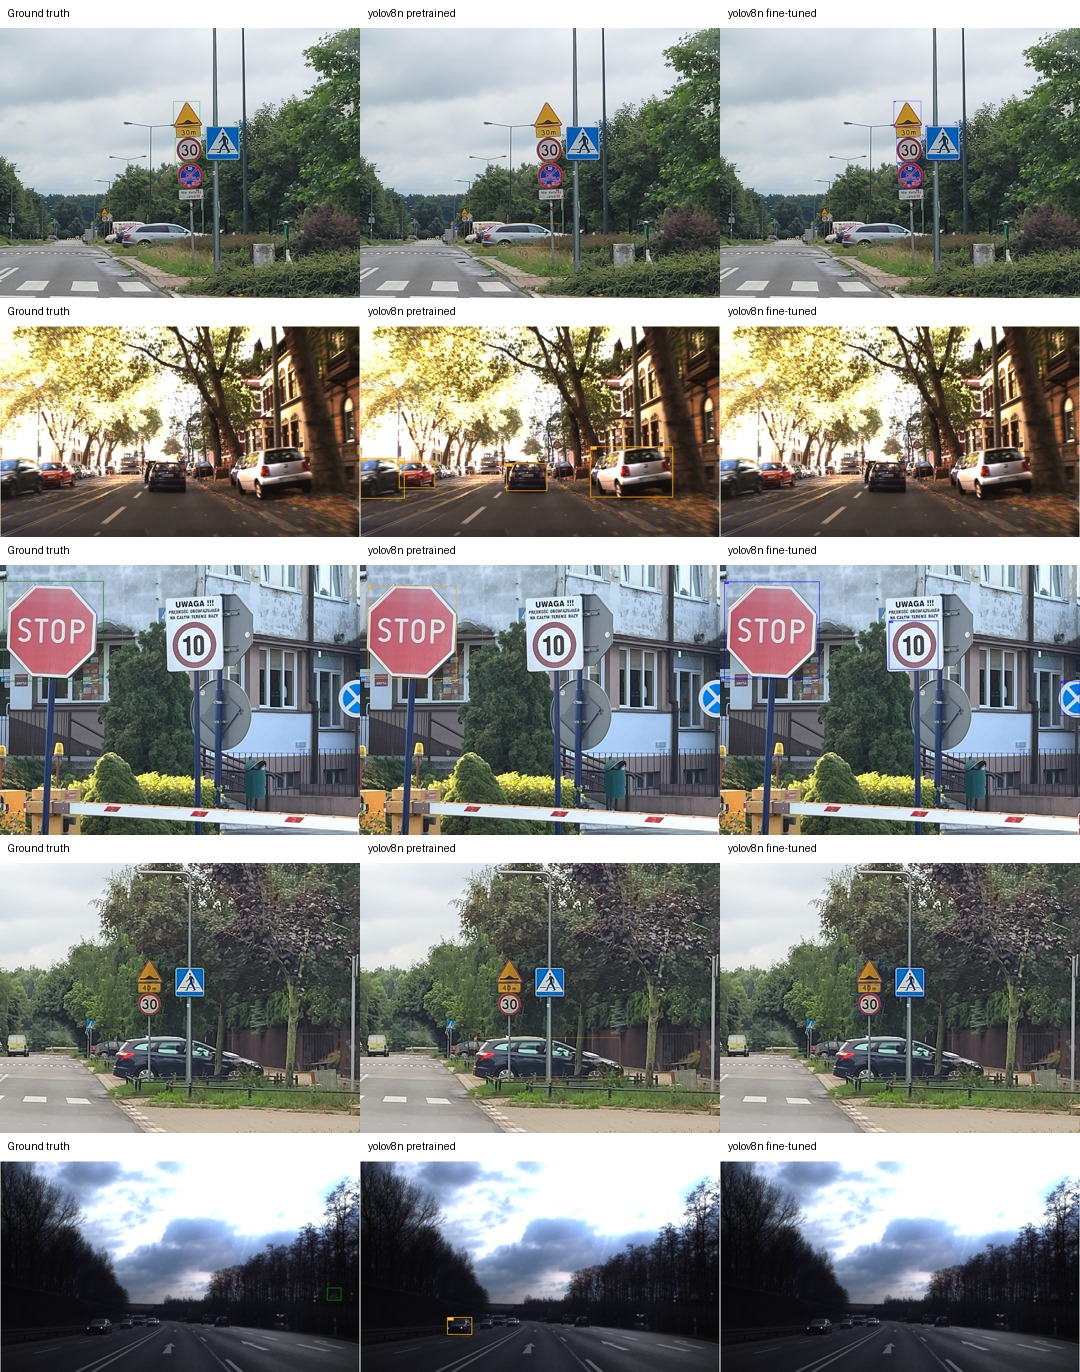

### yolov8n_localization_noaug_20260615-025239

Źródło obrazu: `models/detection/yolov8n_localization_noaug_20260615-025239/visualizations/test_comparison_overview_5samples.jpg`

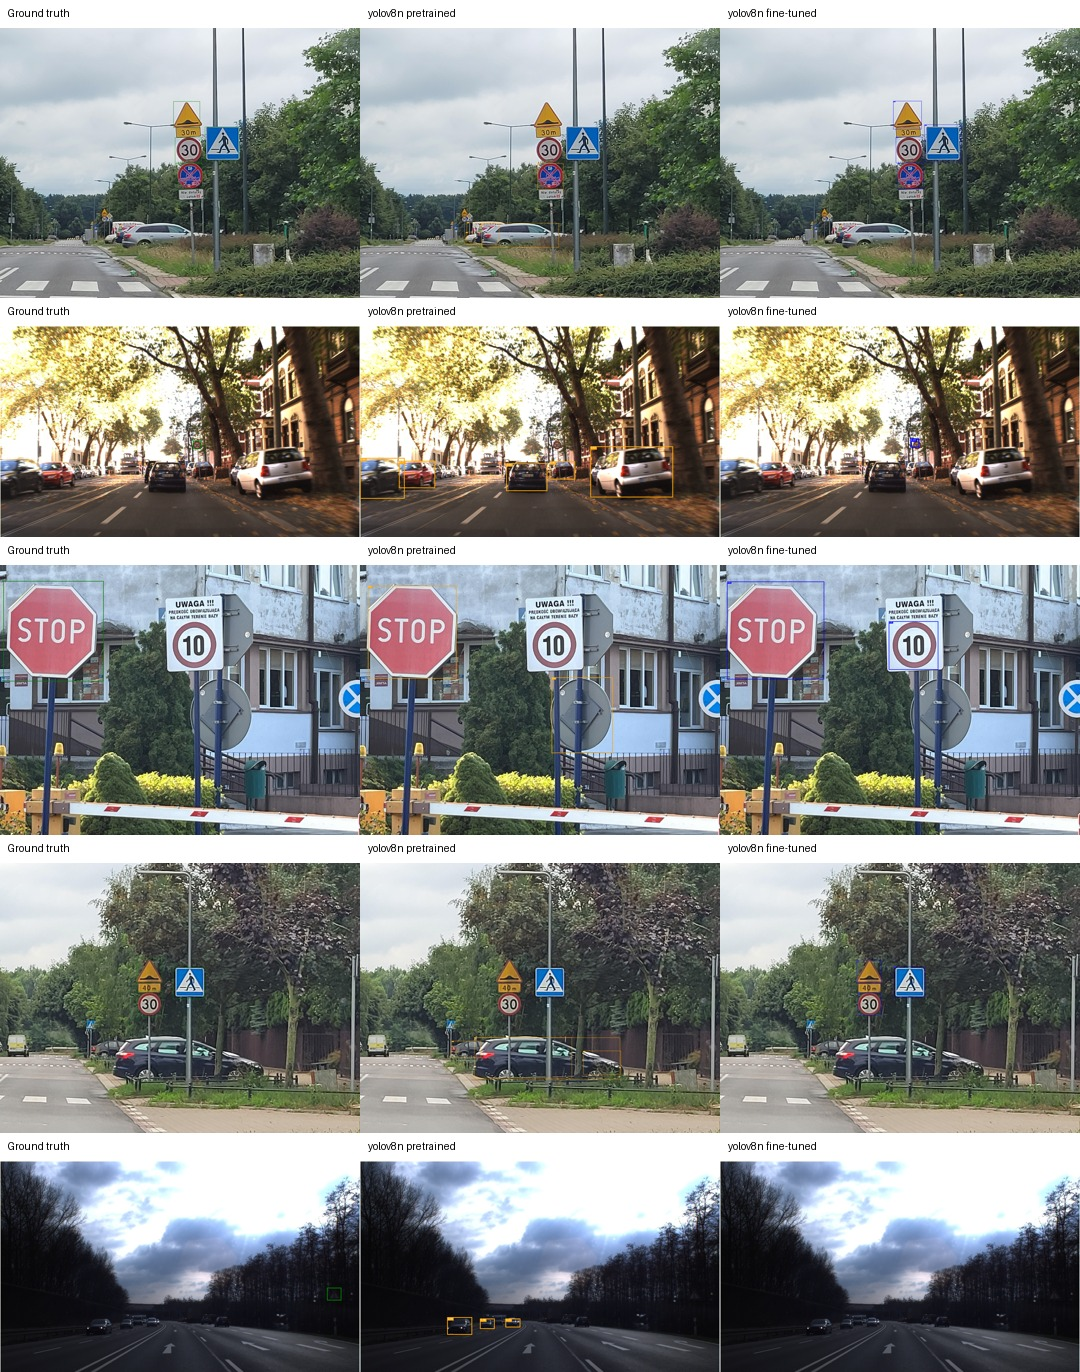

### yolo11n_recognition_20260614-193929

Źródło obrazu: `models/detection/yolo11n_recognition_20260614-193929/visualizations/test_comparison_overview_5samples.jpg`

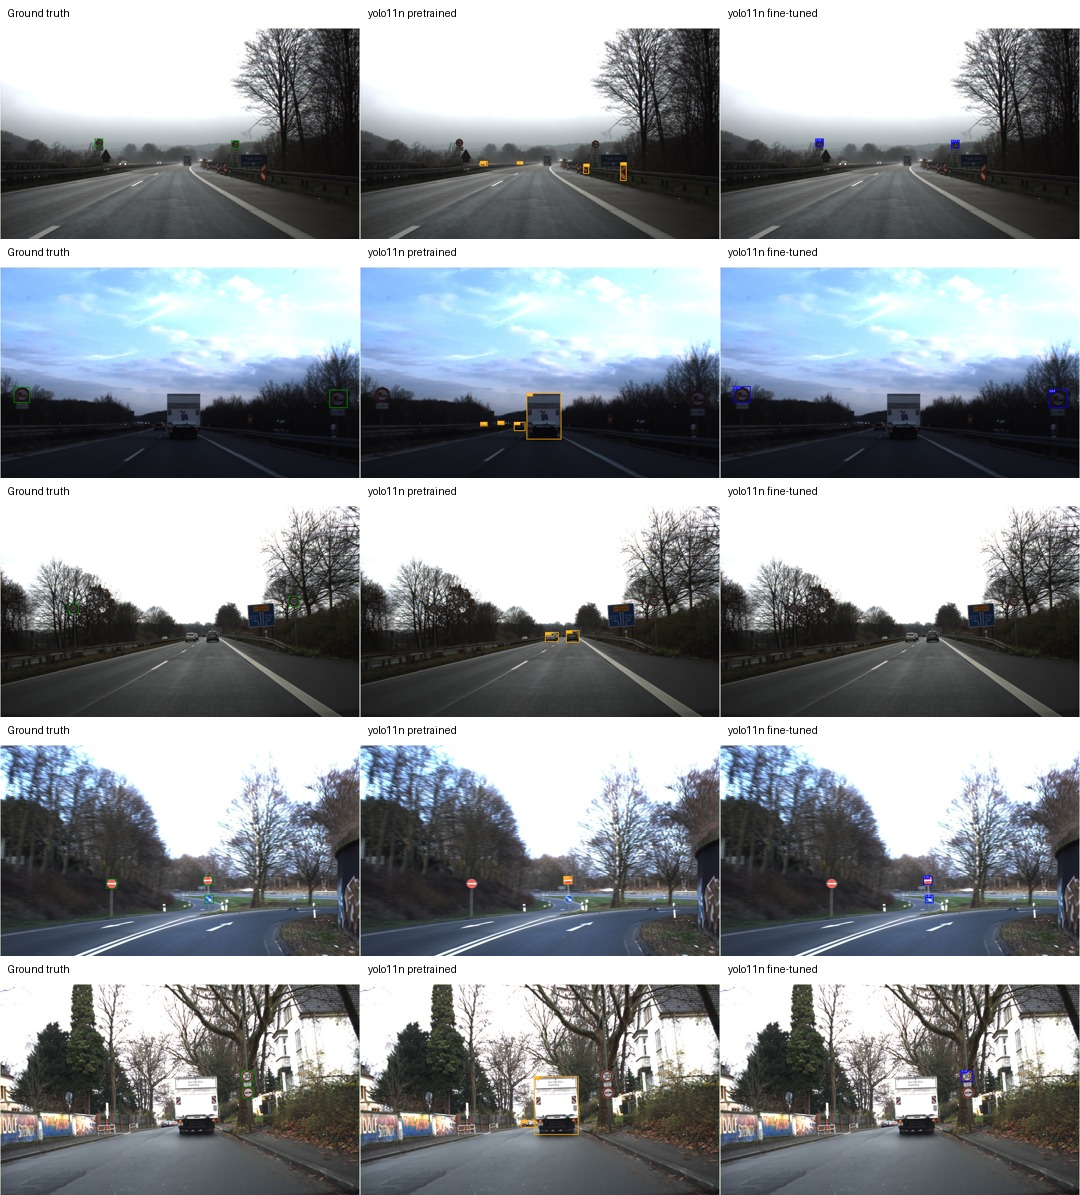

## 6. Wnioski

### Co działa

- **Pipeline dwuetapowy (detektor YOLO + MobileNetV2)** daje najlepszą jakość: detektor lokalizuje znaki z wysokim Recall (do ~97%), a MobileNetV2 klasyfikuje wycinki na 50 klas z Top-1 99.16%.
- **YOLO jako detektor jest uzasadnionym wyborem** - łączy wysoką skuteczność lokalizacji (mAP50 do 93.33%) z możliwością eksportu do TFLite i niewielkim rozmiarem modelu.
- **Fine-tuning na danych `traffic_sign` daje ogromny skok względem baseline'u** - mAP50 wzrasta o ~85 pp względem modelu COCO-pretrained (patrz "Wyniki" → "Porównanie z baseline").
- **Augmentacja danych pomaga detekcji** - w porównaniu kontrolnym wyłączenie augmentacji obniżyło mAP50 i mAP50-95 zarówno dla YOLOv8n, jak i YOLO11n.

### Co nie działa / Ograniczenia

- **Niski Precision@50 dotrenowanych detektorów** (np. 13-18% dla najlepszych modeli pod względem mAP50) - modele generują dużo więcej predykcji niż jest faktycznych znaków (Pred/GT do ~5:1), co w aplikacji wymaga dobrania progu confidence.
- **Model recognition (detekcja+klasyfikacja w jednym kroku) ma niższą jakość i mniejszy zakres klas** niż wariant dwuetapowy (mAP50 77.62% vs 93.33%) - upraszcza wdrożenie, ale kosztem dokładności.
- **Balansowanie klas do średniej (over/under sampling)** poprawiło CustomCNN (+3.7 pp Test Acc) i nieznacznie EfficientNet-Lite0, ale **pogorszyło MobileNetV2** (−1.31 pp vs naturalne próbkowanie, 10 epok). Strategia jest więc pomocna przy słabszych modelach i silnej nierównowadze klas, lecz nie gwarantuje poprawy najlepszego klasyfikatora.
- **Augmentacja danych nie pomogła klasyfikacji przy 5-epokowym treningu** - pogorszyła Test Accuracy dla 3 z 4 klasyfikatorów (CustomCNN, MobileNetV2, SqueezeNet), poprawiając wynik jedynie dla EfficientNet-Lite0. Krótki trening prawdopodobnie nie zdążył wykorzystać dodatkowej wariancji.
- **CustomCNN (sieć od zera) wypada najsłabiej** ze wszystkich klasyfikatorów (Test Acc ~90% vs >96% dla modeli z wagami ImageNet) - brak pretrenowanych wag odbija się na jakości przy krótkim treningu.

### Co zrobiłbym inaczej / co dalej

- Przeprowadzić eksperyment z augmentacją klasyfikacji przy dłuższym treningu (np. 20-30 epok), aby sprawdzić, czy korzyści z augmentacji ujawniają się później.
- Dobrać i skalibrować próg confidence detektora (`--conf`/`--eval-conf`) tak, aby zbalansować Precision i Recall pod kątem realnego użycia w aplikacji, zamiast oceniać tylko przy `eval-conf=0.001`.
- Zbadać, czy zwiększenie liczby epok lub rozmiaru obrazu poprawi Precision modelu recognition bez utraty Recall, zbliżając go do wariantu dwuetapowego.
- Rozszerzyć polski zbiór detekcyjny (obecnie mniejszy niż GTSDB) o więcej scen, aby zmniejszyć zależność detektora od niemieckich danych.

### Rekomendacja

Dla najwyższej jakości użyć `yolo_detector.tflite` do lokalizacji oraz `classifire_mobilenet.tflite` do klasyfikacji wycinka. Jeśli priorytetem jest prostota integracji (jeden model), alternatywą jest `yolo_detector_classifier.tflite`, kosztem niższego mAP50 i mniejszego zakresu klas.

## Dodatek: dane źródłowe (JSON)

Poniższy JSON zawiera dane użyte do tabel.

```json
{
  "classification": [
    {
      "Model": "MobileNetV2",
      "Zadanie": "klasyfikacja wycinków",
      "Liczba klas": 50,
      "Wejście": "224x224",
      "Epoki": 10,
      "Top-1": "99.16%",
      "Top-5": "-",
      "Parametry": "2 287 922"
    },
    {
      "Model": "YOLO11n-cls",
      "Zadanie": "klasyfikacja wycinków",
      "Liczba klas": 50,
      "Wejście": "224x224",
      "Epoki": 50,
      "Top-1": "97.79%",
      "Top-5": "99.98%",
      "Parametry": "-"
    }
  ],
  "classification_balanced_sampling": [
  {
    "Model": "CustomCNN",
    "Run": "custom_cnn_20260615-172105",
    "Sampling": "over_under_to_mean",
    "Epochs": 10,
    "Train Acc": "97.72%",
    "Val Acc": "98.64%",
    "Test Acc": "94.61%",
    "Test Loss": "0.2074",
    "Reference Run": "custom_cnn_20260613-221245",
    "Reference Test Acc": "90.88%",
    "Delta Test Acc": "+3.73 pp"
  },
  {
    "Model": "EfficientNet-Lite0",
    "Run": "efficientnet_lite0_20260615-174658",
    "Sampling": "over_under_to_mean",
    "Epochs": 10,
    "Train Acc": "99.63%",
    "Val Acc": "99.66%",
    "Test Acc": "99.08%",
    "Test Loss": "0.0353",
    "Reference Run": "efficientnet_lite0_20260613-223808",
    "Reference Test Acc": "98.72%",
    "Delta Test Acc": "+0.36 pp"
  },
  {
    "Model": "MobileNetV2",
    "Run": "mobilenet_v2_20260615-181001",
    "Sampling": "over_under_to_mean",
    "Epochs": 10,
    "Train Acc": "99.60%",
    "Val Acc": "99.47%",
    "Test Acc": "97.86%",
    "Test Loss": "0.0872",
    "Reference Run": "mobilenet_v2_20260614-220550",
    "Reference Test Acc": "99.16%",
    "Delta Test Acc": "-1.31 pp"
  },
  {
    "Model": "SqueezeNet",
    "Run": "squeezenet_20260615-182027",
    "Sampling": "over_under_to_mean",
    "Epochs": 10,
    "Train Acc": "98.05%",
    "Val Acc": "97.84%",
    "Test Acc": "95.51%",
    "Test Loss": "0.1891",
    "Reference Run": "squeezenet_20260613-230151",
    "Reference Test Acc": "96.87%",
    "Delta Test Acc": "-1.36 pp"
  }
],
  "classification_augmentation": [
    {
      "Model": "CustomCNN",
      "Wariant": "bez augmentacji",
      "Run": "custom_cnn_20260613-221245",
      "Train Acc": "96.11%",
      "Val Acc": "92.40%",
      "Test Acc": "90.88%",
      "Test Loss": "0.3289"
    },
    {
      "Model": "CustomCNN",
      "Wariant": "z augmentacją",
      "Run": "custom_cnn_20260613-221746",
      "Train Acc": "93.88%",
      "Val Acc": "93.06%",
      "Test Acc": "89.61%",
      "Test Loss": "0.4029"
    },
    {
      "Model": "EfficientNet-Lite0",
      "Wariant": "bez augmentacji",
      "Run": "efficientnet_lite0_20260613-222752",
      "Train Acc": "99.64%",
      "Val Acc": "98.18%",
      "Test Acc": "98.19%",
      "Test Loss": "0.0682"
    },
    {
      "Model": "EfficientNet-Lite0",
      "Wariant": "z augmentacją",
      "Run": "efficientnet_lite0_20260613-223808",
      "Train Acc": "99.60%",
      "Val Acc": "99.72%",
      "Test Acc": "98.72%",
      "Test Loss": "0.0577"
    },
    {
      "Model": "MobileNetV2",
      "Wariant": "bez augmentacji",
      "Run": "mobilenet_v2_20260613-224752",
      "Train Acc": "99.58%",
      "Val Acc": "97.83%",
      "Test Acc": "98.14%",
      "Test Loss": "0.0722"
    },
    {
      "Model": "MobileNetV2",
      "Wariant": "z augmentacją",
      "Run": "mobilenet_v2_20260613-225710",
      "Train Acc": "99.27%",
      "Val Acc": "97.12%",
      "Test Acc": "97.15%",
      "Test Loss": "0.1080"
    },
    {
      "Model": "SqueezeNet",
      "Wariant": "bez augmentacji",
      "Run": "squeezenet_20260613-230151",
      "Train Acc": "98.94%",
      "Val Acc": "97.36%",
      "Test Acc": "96.87%",
      "Test Loss": "0.1530"
    },
    {
      "Model": "SqueezeNet",
      "Wariant": "z augmentacją",
      "Run": "squeezenet_20260613-230713",
      "Train Acc": "98.11%",
      "Val Acc": "96.55%",
      "Test Acc": "96.39%",
      "Test Loss": "0.1552"
    }
  ],
  "classification_augmentation_delta": [
    {
      "Model": "CustomCNN",
      "Zmiana Test Acc": "-1.27 pp",
      "Zmiana Test Loss": "+0.0740",
      "Interpretacja": "pogorszenie"
    },
    {
      "Model": "EfficientNet-Lite0",
      "Zmiana Test Acc": "+0.53 pp",
      "Zmiana Test Loss": "-0.0105",
      "Interpretacja": "poprawa"
    },
    {
      "Model": "MobileNetV2",
      "Zmiana Test Acc": "-0.99 pp",
      "Zmiana Test Loss": "+0.0358",
      "Interpretacja": "pogorszenie"
    },
    {
      "Model": "SqueezeNet",
      "Zmiana Test Acc": "-0.48 pp",
      "Zmiana Test Loss": "+0.0022",
      "Interpretacja": "nieznaczne pogorszenie"
    }
  ],
  "localization": [
    {
      "Run": "yolo11n_traffic_sign_20260613-222305",
      "Model bazowy": "yolov8n.pt",
      "Augmentacja": "domyślna YOLO",
      "Wejście": "320x320",
      "Precision@50": "18.36%",
      "Recall@50": "97.16%",
      "F1@50": "30.89%",
      "mAP50": "93.33%",
      "mAP50-95": "71.02%",
      "Pred / GT": "3 164 / 598"
    },
    {
      "Run": "yolo11n_traffic_sign_20260613-205016",
      "Model bazowy": "yolo11n.pt",
      "Augmentacja": "domyślna YOLO",
      "Wejście": "320x320",
      "Precision@50": "14.26%",
      "Recall@50": "96.32%",
      "F1@50": "24.85%",
      "mAP50": "93.30%",
      "mAP50-95": "71.00%",
      "Pred / GT": "4 038 / 598"
    },
    {
      "Run": "yolo11n_traffic_sign_20260613-234452",
      "Model bazowy": "yolov8n.pt",
      "Augmentacja": "domyślna YOLO",
      "Wejście": "320x320",
      "Precision@50": "87.38%",
      "Recall@50": "90.30%",
      "F1@50": "88.82%",
      "mAP50": "89.38%",
      "mAP50-95": "70.19%",
      "Pred / GT": "618 / 598"
    },
    {
      "Run": "yolo11n_traffic_sign_20260613-230547",
      "Model bazowy": "yolo11n.pt",
      "Augmentacja": "domyślna YOLO",
      "Wejście": "320x320",
      "Precision@50": "85.03%",
      "Recall@50": "89.30%",
      "F1@50": "87.11%",
      "mAP50": "88.18%",
      "mAP50-95": "69.04%",
      "Pred / GT": "628 / 598"
    },
    {
      "Run": "yolov8n_localization_20260615-013627",
      "Model bazowy": "yolov8n.pt",
      "Augmentacja": "domyślna YOLO",
      "Wejście": "320x320",
      "Precision@50": "94.26%",
      "Recall@50": "85.12%",
      "F1@50": "89.46%",
      "mAP50": "84.61%",
      "mAP50-95": "67.38%",
      "Pred / GT": "540 / 598"
    },
    {
      "Run": "yolov8n_localization_noaug_20260615-025239",
      "Model bazowy": "yolov8n.pt",
      "Augmentacja": "wyłączona",
      "Wejście": "320x320",
      "Precision@50": "64.93%",
      "Recall@50": "87.29%",
      "F1@50": "74.47%",
      "mAP50": "84.23%",
      "mAP50-95": "61.65%",
      "Pred / GT": "804 / 598"
    },
    {
      "Run": "yolo11n_localization_noaug_20260615-030149",
      "Model bazowy": "yolo11n.pt",
      "Augmentacja": "wyłączona",
      "Wejście": "320x320",
      "Precision@50": "29.88%",
      "Recall@50": "89.13%",
      "F1@50": "44.75%",
      "mAP50": "84.05%",
      "mAP50-95": "60.12%",
      "Pred / GT": "1 784 / 598"
    }
  ],
  "augmentation_ablation": [
    {
      "Model": "YOLOv8n",
      "Wariant": "z augmentacją",
      "Run": "yolov8n_localization_20260615-013627",
      "mAP50": "84.61%",
      "mAP50-95": "67.38%",
      "Precision@50": "94.26%",
      "Recall@50": "85.12%",
      "Pred / GT": "540 / 598"
    },
    {
      "Model": "YOLOv8n",
      "Wariant": "bez augmentacji",
      "Run": "yolov8n_localization_noaug_20260615-025239",
      "mAP50": "84.23%",
      "mAP50-95": "61.65%",
      "Precision@50": "64.93%",
      "Recall@50": "87.29%",
      "Pred / GT": "804 / 598"
    },
    {
      "Model": "YOLO11n",
      "Wariant": "z augmentacją",
      "Run": "yolo11n_traffic_sign_20260613-205016",
      "mAP50": "93.30%",
      "mAP50-95": "71.00%",
      "Precision@50": "14.26%",
      "Recall@50": "96.32%",
      "Pred / GT": "4 038 / 598"
    },
    {
      "Model": "YOLO11n",
      "Wariant": "bez augmentacji",
      "Run": "yolo11n_localization_noaug_20260615-030149",
      "mAP50": "84.05%",
      "mAP50-95": "60.12%",
      "Precision@50": "29.88%",
      "Recall@50": "89.13%",
      "Pred / GT": "1 784 / 598"
    }
  ],
  "augmentation_delta": [
    {
      "Model": "YOLOv8n",
      "Zmiana mAP50 po wyłączeniu": "-0.38 pp",
      "Zmiana mAP50-95 po wyłączeniu": "-5.73 pp",
      "Zmiana Precision@50": "-29.33 pp",
      "Zmiana Recall@50": "+2.17 pp",
      "Interpretacja": "pogorszenie jakości po wyłączeniu augmentacji"
    },
    {
      "Model": "YOLO11n",
      "Zmiana mAP50 po wyłączeniu": "-9.25 pp",
      "Zmiana mAP50-95 po wyłączeniu": "-10.88 pp",
      "Zmiana Precision@50": "+15.61 pp",
      "Zmiana Recall@50": "-7.19 pp",
      "Interpretacja": "pogorszenie jakości po wyłączeniu augmentacji"
    }
  ],
  "recognition": [
    {
      "Run": "yolo11n_recognition_20260614-193929",
      "Wejście": "640x640",
      "Epoki": 100,
      "Precision@50": "11.33%",
      "Recall@50": "98.65%",
      "F1@50": "20.32%",
      "mAP50": "77.62%",
      "mAP50-95": "59.98%"
    },
    {
      "Run": "yolo11n_recognition_20260614-193320",
      "Wejście": "320x320",
      "Epoki": 50,
      "Precision@50": "8.94%",
      "Recall@50": "80.41%",
      "F1@50": "16.09%",
      "mAP50": "53.13%",
      "mAP50-95": "28.04%"
    }
  ],
  "tflite": [
    {
      "Model / wariant": "YOLO lokalizacyjny",
      "Plik": "models/tflite/yolo_detector.tflite",
      "Rozmiar": "11.57 MB",
      "Wejście": "[1, 320, 320, 3]",
      "Wyjście": "[1, 5, 2100]"
    },
    {
      "Model / wariant": "MobileNetV2",
      "Plik": "models/tflite/classifire_mobilenet.tflite",
      "Rozmiar": "8.69 MB",
      "Wejście": "[1, 224, 224, 3]",
      "Wyjście": "[1, 50]"
    },
    {
      "Model / wariant": "YOLO recognition",
      "Plik": "models/tflite/yolo_detector_classifier.tflite",
      "Rozmiar": "10.15 MB",
      "Wejście": "[1, 640, 640, 3]",
      "Wyjście": "[1, 47, 8400]"
    },
    {
      "Model / wariant": "YOLO11n-cls",
      "Plik": "models/classification_yolo/yolo11n-cls_20260614-201616/weights/best_saved_model/best_float32.tflite",
      "Rozmiar": "6.10 MB",
      "Wejście": "[1, 224, 224, 3]",
      "Wyjście": "[1, 50]"
    }
  ],
  "baseline_comparison": [
    {
      "Run": "yolo11n_traffic_sign_20260614-204831",
      "Model bazowy": "yolo11n.pt",
      "Etap": "baseline (COCO-pretrained)",
      "mAP50": "7.37%",
      "Recall@50": "74.08%",
      "Precision@50": "2.19%"
    },
    {
      "Run": "yolo11n_traffic_sign_20260614-204831",
      "Model bazowy": "yolo11n.pt",
      "Etap": "po fine-tuningu",
      "mAP50": "92.90%",
      "Recall@50": "96.32%",
      "Precision@50": "13.80%"
    },
    {
      "Run": "yolo11n_traffic_sign_20260614-210909",
      "Model bazowy": "yolov8n.pt",
      "Etap": "baseline (COCO-pretrained)",
      "mAP50": "6.90%",
      "Recall@50": "74.58%",
      "Precision@50": "2.17%"
    },
    {
      "Run": "yolo11n_traffic_sign_20260614-210909",
      "Model bazowy": "yolov8n.pt",
      "Etap": "po fine-tuningu",
      "mAP50": "92.55%",
      "Recall@50": "95.65%",
      "Precision@50": "15.87%"
    }
  ]
}
```